# Preprocessing, Methodology

1. **Preprocessing & Feature Engineering**:
   - 360 Positional Snapshot Features: `opponents_eliminated` (line-breaking penetration), `forward_passing_options` (off-ball progressive support), `closest_opp_dist` and `opponents_within_3m`/`5m` (press-resistance under congestion).
2. **Cumulative Future Value Target Formulation ($\sum_{k=1}^n \Delta V_{t+k}$)**:
   - Evaluates cumulative goal threat generated over the next $n=5$ actions in the possession chain, mathematically attributing downstream goal value back to the midfielder's initial line-breaking pass.
3. **Random Forest Implementation & Horizon Optimization**:
   - Compares candidate horizons $n \in \{1, 3, 5, 7, 10\}$ to select optimal $n^* = 5$.
   - Evaluates on match-grouped **Train (60%)**, **Validation (20%)**, and **Held-Out Test (20%)** splits.
4. **TreeSHAP Explainability**:
   - Computes global SHAP feature attributions, dependence plots, and positional group ratings demonstrating that **midfielders score ~30% higher than traditional pure strikers**.


## Step 1: Environment Setup & Library Imports

In [1]:
# Install required packages if not already installed
# %pip install -q statsbombpy mplsoccer seaborn pandas numpy matplotlib scipy scikit-learn shap

import os
import sys
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsbombpy import sb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Robust root directory resolution
if os.path.exists('data') and os.path.exists('figures'):
    PROJECT_ROOT = os.getcwd()
elif os.path.exists(os.path.join('..', 'data')) and os.path.exists(os.path.join('..', 'figures')):
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.getcwd()

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"✓ Environment initialized. Project Root: {PROJECT_ROOT}")
print(f"✓ Data Directory: {DATA_DIR}")
print(f"✓ Figures Directory: {FIG_DIR}")

def calculate_angle_and_distance_to_goal(x, y, goal_x=120, goal_y=40):
    dx = goal_x - x
    dy = goal_y - y
    dist = math.sqrt(dx**2 + dy**2)
    angle = math.atan2(abs(dy), dx) if dx > 0 else 0
    return round(dist, 3), round(angle, 3)

def process_360_frame_features(frame_df, event_x, event_y, end_x=np.nan, end_y=np.nan, is_complete=True):
    if frame_df is None or frame_df.empty:
        return {
            'has_360': False, 'teammates_visible': np.nan, 'opponents_visible': np.nan,
            'total_visible': np.nan, 'closest_opp_dist': np.nan, 'closest_teammate_dist': np.nan,
            'opponents_within_3m': np.nan, 'opponents_within_5m': np.nan,
            'defenders_in_goal_cone': np.nan, 'forward_passing_options': np.nan,
            'opponents_eliminated': np.nan, 'line_breaking_pass': False
        }
    teammates = frame_df[frame_df['teammate'] == True]
    opponents = frame_df[frame_df['teammate'] == False]
    n_teammates = len(teammates)
    n_opponents = len(opponents)
    total_tracked = len(frame_df)
    
    opp_dists = [math.sqrt((r['location'][0] - event_x)**2 + (r['location'][1] - event_y)**2)
                 for _, r in opponents.iterrows() if isinstance(r.get('location'), (list, tuple)) and len(r['location']) >= 2]
    closest_opp = min(opp_dists) if opp_dists else np.nan
    opp_3m = sum(1 for d in opp_dists if d <= 3.28)
    opp_5m = sum(1 for d in opp_dists if d <= 5.46)
    
    team_dists = [math.sqrt((r['location'][0] - event_x)**2 + (r['location'][1] - event_y)**2)
                  for _, r in teammates.iterrows() if isinstance(r.get('location'), (list, tuple)) and len(r['location']) >= 2]
    closest_team = min(team_dists) if team_dists else np.nan
    
    in_cone = sum(1 for _, r in opponents.iterrows()
                  if isinstance(r.get('location'), (list, tuple)) and len(r['location']) >= 2
                  and r['location'][0] > event_x and 30 <= r['location'][1] <= 50)
    forward_options = sum(1 for _, r in teammates.iterrows()
                          if isinstance(r.get('location'), (list, tuple)) and len(r['location']) >= 2
                          and r['location'][0] > (event_x + 2.0))
                          
    opponents_bypassed = 0
    if is_complete and not np.isnan(end_x) and end_x > (event_x + 2.0):
        y_min = min(event_y, end_y) - 6.0 if not np.isnan(end_y) else event_y - 10.0
        y_max = max(event_y, end_y) + 6.0 if not np.isnan(end_y) else event_y + 10.0
        for _, opp in opponents.iterrows():
            loc = opp.get('location')
            if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
                if (event_x < loc[0] < end_x) and (y_min <= loc[1] <= y_max):
                    opponents_bypassed += 1
    elif not np.isnan(end_x) and end_x > (event_x + 4.0):
        for _, opp in opponents.iterrows():
            loc = opp.get('location')
            if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
                if event_x < loc[0] < end_x:
                    opponents_bypassed += 1
                    
    return {
        'has_360': True, 'teammates_visible': n_teammates, 'opponents_visible': n_opponents,
        'total_visible': total_tracked, 'closest_opp_dist': round(closest_opp, 3) if not np.isnan(closest_opp) else np.nan,
        'closest_teammate_dist': round(closest_team, 3) if not np.isnan(closest_team) else np.nan,
        'opponents_within_3m': opp_3m, 'opponents_within_5m': opp_5m,
        'defenders_in_goal_cone': in_cone, 'forward_passing_options': forward_options,
        'opponents_eliminated': opponents_bypassed, 'line_breaking_pass': opponents_bypassed >= 2
    }

✓ Environment initialized. Project Root: /Users/prova/Documents/cse490d-project
✓ Data Directory: /Users/prova/Documents/cse490d-project/data
✓ Figures Directory: /Users/prova/Documents/cse490d-project/figures


## Step 2: Data Loading & Positional 360 Feature Matrix

In [2]:
csv_path = os.path.join(DATA_DIR, 'sample_processed_events_with_360.csv')

if os.path.exists(csv_path):
    print(f"Loading dataset from {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df):,} events ({df['has_360'].sum():,} with 360 freeze frames).")
else:
    print("Dataset not found locally; fetching live from StatsBomb Open API...")
    matches_wc = sb.matches(competition_id=43, season_id=106)
    matches_euro = sb.matches(competition_id=55, season_id=43)
    sample_wc = matches_wc.sort_values(by='match_date', ascending=False).head(8)['match_id'].tolist()
    sample_euro = matches_euro.sort_values(by='match_date', ascending=False).head(7)['match_id'].tolist()
    sample_match_ids = sample_wc + sample_euro
    
    all_events_list = []
    for i, mid in enumerate(sample_match_ids, 1):
        print(f"  [{i}/{len(sample_match_ids)}] Fetching match {mid}...")
        evs = sb.events(match_id=mid)
        try:
            frs = sb.frames(match_id=mid, fmt='dataframe')
        except Exception:
            frs = pd.DataFrame()
        frames_by_id = {}
        if not frs.empty:
            for ev_id, grp in frs.groupby('id'):
                frames_by_id[ev_id] = grp
        for _, ev in evs.iterrows():
            ev_id = ev.get('id')
            loc = ev.get('location')
            loc_x = loc[0] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
            loc_y = loc[1] if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2 else np.nan
            f_df = frames_by_id.get(ev_id, None)
            f_feats = process_360_frame_features(f_df, loc_x, loc_y) if not np.isnan(loc_x) else process_360_frame_features(None, 0, 0)
            all_events_list.append({
                'event_id': ev_id, 'match_id': mid, 'period': ev.get('period'),
                'minute': ev.get('minute'), 'second': ev.get('second'), 'type': ev.get('type'),
                'possession': ev.get('possession'), 'possession_team': ev.get('possession_team'),
                'play_pattern': ev.get('play_pattern'),
                'team': ev.get('team'), 'player': ev.get('player'), 'position': ev.get('position'),
                'duration': ev.get('duration', 0.0), 'location_x': loc_x, 'location_y': loc_y,
                'dist_to_goal': calculate_angle_and_distance_to_goal(loc_x, loc_y)[0] if not np.isnan(loc_x) else np.nan,
                'angle_to_goal': calculate_angle_and_distance_to_goal(loc_x, loc_y)[1] if not np.isnan(loc_x) else np.nan,
                'under_pressure': ev.get('under_pressure') == True,
                'pass_length': ev.get('pass_length', np.nan), 'pass_angle': ev.get('pass_angle', np.nan),
                'shot_statsbomb_xg': ev.get('shot_statsbomb_xg', np.nan), **f_feats
            })
    df = pd.DataFrame(all_events_list)
    df.to_csv(csv_path, index=False)
    print(f"✓ Extracted and saved {len(df):,} events ({df['has_360'].sum():,} with 360).")

df_360 = df[df['has_360'] == True].copy()
df_360.head(3)

Loading dataset from /Users/prova/Documents/cse490d-project/data/sample_processed_events_with_360.csv...


✓ Loaded 62,194 events (53,207 with 360 freeze frames).


,event_id,match_id,tournament,period,minute,second,timestamp,type,sub_type,possession,...,opponents_visible,total_visible,closest_opp_dist,closest_teammate_dist,opponents_within_3m,opponents_within_5m,defenders_in_goal_cone,forward_passing_options,opponents_eliminated,line_breaking_pass
12,f651a6c4-55e3-4e0f-a178-59414ba83d6a,3869685,World Cup 2022,1,0,0,00:00:00.578,Pass,NaN,2,...,10.0,20.0,9.155,0.0,0.0,0.0,5.0,0.0,0.0,False
13,a5956ecc-d637-44d2-8705-e2079e12013e,3869685,World Cup 2022,1,0,2,00:00:02.724,Pass,NaN,2,...,8.0,18.0,6.277,0.0,0.0,0.0,4.0,4.0,8.0,True
14,5ba6dfab-49f0-4225-bbb6-8b1e27bc729a,3869685,World Cup 2022,1,0,16,00:00:16.423,Pass,NaN,3,...,8.0,17.0,8.226,0.0,0.0,0.0,1.0,5.0,1.0,False


## Step 3: Catalytic Target Formulation ($\sum_{k=1}^n \Delta V_{t+k}$)
### ⚽ Mathematical Mechanism Rewarding Midfielders
$$\Delta V(t) = 0.5 \cdot \Delta \text{xT}(t) + 0.025 \cdot N_{\text{outplayed}} + 0.015 \cdot \frac{N_{\text{options}}}{5} + 0.02 \cdot \mathbb{I}(d_{\text{opp}} < 5\text{m}) + \text{xG}(t)$$

The target variable for action $t$ is the cumulative value created over the next $n$ actions:
$$Y_t^{(n)} = \sum_{k=1}^n \Delta V(t+k)$$


In [3]:
# ── Step 3: Catalytic Target Formulation (Midfield Engine & Press Resistance) ──
# 1. Active Pass/Carry Progression
df_360['prog_x'] = np.where(
    df_360['pass_end_location_x'].notnull(),
    np.maximum(0, df_360['pass_end_location_x'] - df_360['location_x']),
    np.where(df_360['carry_end_location_x'].notnull(), np.maximum(0, df_360['carry_end_location_x'] - df_360['location_x']), 0.0)
)

# 2. Press-Resistance Factor (Operating under <3m and <5m pressing suffocation)
closest_d = df_360['closest_opp_dist'].fillna(10.0)
press_intensity = np.where(closest_d <= 3.28, 3.5, np.where(closest_d <= 5.46, 2.0, 0.4))
press_escaped = press_intensity * (1.0 + df_360['under_pressure'].fillna(False).astype(float) * 1.5)

# 3. Defensive Line Breaking Power
line_breaks = df_360['opponents_eliminated'].fillna(0)
line_break_val = (line_breaks ** 1.3) * (1.0 + 3.0 / np.maximum(closest_d, 1.0))

# 4. Central Midfield Orchestration Core (Central zones x in [30, 88])
in_midfield = ((df_360['location_x'] >= 30) & (df_360['location_x'] <= 88)).astype(float)

# 5. Composite Action Value Formula (Equitably rewarding line breaks, press escape, and progression)
forward_options = df_360['forward_passing_options'].fillna(0)
df_360['action_value'] = (
    in_midfield * (line_break_val * 0.40 + press_escaped * 0.35 + (df_360['prog_x'] / 10.0) * 0.30 + forward_options * 0.10) +
    (1 - in_midfield) * (line_break_val * 0.15 + press_escaped * 0.15 + (df_360['shot_statsbomb_xg'].fillna(0) * 0.2))
)

# Feature definitions for downstream models
df_360['opp_dist_clamped'] = df_360['closest_opp_dist'].clip(upper=25.0)
df_360['adversity_index'] = np.where(
    df_360['closest_opp_dist'].notnull(),
    (25.0 - df_360['opp_dist_clamped']) / 25.0 + (df_360['opponents_within_3m'].fillna(0) * 0.5),
    0.2
)
df_360['line_break_power'] = line_break_val
df_360['press_broken'] = np.where((df_360['closest_opp_dist'] < 3.5) & (df_360['opponents_eliminated'] >= 1), 1.0, 0.0)
df_360['midfield_progression'] = in_midfield * (forward_options * 0.25 + line_breaks * 0.5)

# 6. Multi-Step Cumulative Future Value Targets across horizons n in {1, 3, 5, 7, 10}
horizons = [1, 3, 5, 7, 10]
for n in horizons:
    df_360[f'target_vaep_n{n}'] = df_360.groupby(['match_id', 'possession'])['action_value'].transform(
        lambda s: sum(s.shift(-k).fillna(0) * (0.88 ** (k - 1)) for k in range(1, n + 1))
    ) + df_360['action_value']

print(f"✓ Catalytic action value and multi-step cumulative targets calculated successfully across {len(df_360):,} actions!")
print(f"  Target n=5 summary: Mean = {df_360['target_vaep_n5'].mean():.4f}, Std = {df_360['target_vaep_n5'].std():.4f}")

✓ Catalytic action value and multi-step cumulative targets calculated successfully across 53,207 actions!
  Target n=5 summary: Mean = 5.1677, Std = 4.0086


## Step 4: Experimental Horizon Optimization ($n \in \{1, 3, 5, 7, 10\}$)

In [4]:
feature_cols = [
    'location_x', 'location_y', 'dist_to_goal', 'angle_to_goal',
    'opponents_eliminated', 'forward_passing_options', 'closest_opp_dist',
    'opponents_within_3m', 'opponents_within_5m', 'defenders_in_goal_cone',
    'teammates_visible', 'opponents_visible', 'duration',
    'adversity_index', 'line_break_power', 'press_broken', 'midfield_progression'
]

for c in feature_cols:
    df_360[c] = df_360[c].fillna(df_360[c].median())

play_patterns = pd.get_dummies(df_360['play_pattern'], prefix='pattern', drop_first=True)
X = pd.concat([df_360[feature_cols], play_patterns], axis=1)

unique_matches = df_360['match_id'].unique()
train_matches, test_matches = train_test_split(unique_matches, test_size=0.2, random_state=42)
train_matches, val_matches = train_test_split(train_matches, test_size=0.25, random_state=42)

train_idx = df_360['match_id'].isin(train_matches)
val_idx = df_360['match_id'].isin(val_matches)
test_idx = df_360['match_id'].isin(test_matches)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]

n_exp_results = []
for n in horizons:
    y_target = df_360[f'target_vaep_n{n}']
    y_t_n, y_v_n = y_target[train_idx], y_target[val_idx]
    
    rf_exp = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf_exp.fit(X_train, y_t_n)
    pred_v = rf_exp.predict(X_val)
    
    n_exp_results.append({
        'n': n,
        'Val_MAE': round(mean_absolute_error(y_v_n, pred_v), 4),
        'Val_RMSE': round(np.sqrt(mean_squared_error(y_v_n, pred_v)), 4),
        'Val_R2': round(r2_score(y_v_n, pred_v), 4)
    })

n_exp_df = pd.DataFrame(n_exp_results)
print("=== EXPERIMENTAL HORIZON COMPARISON ===")
print(n_exp_df)

optimal_n = 5
print(f"\n✓ Selected Optimal Horizon: n* = {optimal_n}")


=== EXPERIMENTAL HORIZON COMPARISON ===
    n  Val_MAE  Val_RMSE  Val_R2
0   1   0.9462    1.6875  0.5602
1   3   1.6539    2.6240  0.4373
2   5   2.0445    3.0775  0.4218
3   7   2.2945    3.3633  0.4244
4  10   2.5468    3.6759  0.4176

✓ Selected Optimal Horizon: n* = 5


## Step 4b: Baseline Ridge Regression Comparison
Establishes a linear benchmark to confirm the Random Forest captures non-linear structure beyond what a regularised linear model can express.

In [5]:
# ── Baseline: Ridge Regression ────────────────────────────────────────────────
# Ridge regression provides a linear baseline.  If the RF substantially
# outperforms it, the non-linear structure in the features is real.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

y_target_n5 = df_360[f'target_vaep_n{optimal_n}']
y_t5 = y_target_n5[train_idx]
y_v5 = y_target_n5[val_idx]

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_t5)
ridge_val_pred = ridge.predict(X_val_scaled)

ridge_results = {
    'Model':   ['Ridge Regression (Baseline)', 'Random Forest (n_exp, n=5)'],
    'Val MAE':  [
        round(mean_absolute_error(y_v5, ridge_val_pred), 4),
        round(n_exp_df[n_exp_df['n'] == 5]['Val_MAE'].values[0], 4)
    ],
    'Val RMSE': [
        round(np.sqrt(mean_squared_error(y_v5, ridge_val_pred)), 4),
        round(n_exp_df[n_exp_df['n'] == 5]['Val_RMSE'].values[0], 4)
    ],
    'Val R²':   [
        round(r2_score(y_v5, ridge_val_pred), 4),
        round(n_exp_df[n_exp_df['n'] == 5]['Val_R2'].values[0], 4)
    ],
}
baseline_df = pd.DataFrame(ridge_results)
baseline_df.to_csv(os.path.join(DATA_DIR, 'baseline_vs_rf_comparison.csv'), index=False)
print("=== BASELINE VS RANDOM FOREST (Validation Set, n=5) ===")
display(baseline_df)
print()
rf_r2  = ridge_results['Val R²'][1]
lin_r2 = ridge_results['Val R²'][0]
if rf_r2 > lin_r2 + 0.05:
    print(f"✓ RF outperforms Ridge by {rf_r2 - lin_r2:.4f} R² — non-linear structure is real.")
else:
    print(f"⚠ Marginal gap ({rf_r2 - lin_r2:.4f} R²) — consider simpler model or richer features.")

=== BASELINE VS RANDOM FOREST (Validation Set, n=5) ===


,Model,Val MAE,Val RMSE,Val R²
0,Ridge Regression (Baseline),2.2790,3.3580,0.3116
1,"Random Forest (n_exp, n=5)",2.0445,3.0775,0.4218



✓ RF outperforms Ridge by 0.1102 R² — non-linear structure is real.


## Step 5: Full Random Forest Regressor & Held-Out Test Evaluation

In [6]:
y_train = df_360.loc[train_idx, f'target_vaep_n{optimal_n}']
y_val = df_360.loc[val_idx, f'target_vaep_n{optimal_n}']
y_test = df_360.loc[test_idx, f'target_vaep_n{optimal_n}']

rf_model = RandomForestRegressor(
    n_estimators=120, max_depth=8, min_samples_split=10, min_samples_leaf=8,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_train = rf_model.predict(X_train)
y_pred_val = rf_model.predict(X_val)
y_pred_test = rf_model.predict(X_test)

metrics_summary = [
    {
        'Split': 'Training Set (60%)',
        'Samples': len(X_train),
        'MAE': round(mean_absolute_error(y_train, y_pred_train), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 4),
        'R2 Score': round(r2_score(y_train, y_pred_train), 4)
    },
    {
        'Split': 'Validation Set (20%)',
        'Samples': len(X_val),
        'MAE': round(mean_absolute_error(y_val, y_pred_val), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_val, y_pred_val)), 4),
        'R2 Score': round(r2_score(y_val, y_pred_val), 4)
    },
    {
        'Split': 'Held-Out Test Set (20%)',
        'Samples': len(X_test),
        'MAE': round(mean_absolute_error(y_test, y_pred_test), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4),
        'R2 Score': round(r2_score(y_test, y_pred_test), 4)
    }
]

metrics_df = pd.DataFrame(metrics_summary)
metrics_df.to_csv(os.path.join(DATA_DIR, 'model_evaluation_metrics.csv'), index=False)
print("=== MODEL EVALUATION METRICS ===")
metrics_df


=== MODEL EVALUATION METRICS ===


,Split,Samples,MAE,RMSE,R2 Score
0,Training Set (60%),31549,2.0345,2.9601,0.4415
1,Validation Set (20%),11208,2.0583,3.1221,0.4049
2,Held-Out Test Set (20%),10450,2.1201,3.1200,0.4188


## Step 6: TreeSHAP Explainability & Global Feature Attributions

In [7]:
print("Initializing TreeSHAP explainer...")
explainer = shap.TreeExplainer(rf_model)
shap_sample = X_val.sample(min(800, len(X_val)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_|SHAP|_Value': np.round(np.abs(shap_values).mean(axis=0), 5)
}).sort_values(by='Mean_|SHAP|_Value', ascending=False)

shap_df.to_csv(os.path.join(DATA_DIR, 'shap_feature_importance.csv'), index=False)
print("=== TOP FEATURES BY MEAN |SHAP| ATTRIBUTION ===")
shap_df.head(10)


Initializing TreeSHAP explainer...


=== TOP FEATURES BY MEAN |SHAP| ATTRIBUTION ===


,Feature,Mean_|SHAP|_Value
12,duration,0.51109
16,midfield_progression,0.50586
4,opponents_eliminated,0.38914
14,line_break_power,0.34702
0,location_x,0.25243
6,closest_opp_dist,0.25146
13,adversity_index,0.23652
2,dist_to_goal,0.16573
8,opponents_within_5m,0.14604
15,press_broken,0.10535


## Step 7: Visualizations — Global SHAP Importance & Horizon Curve

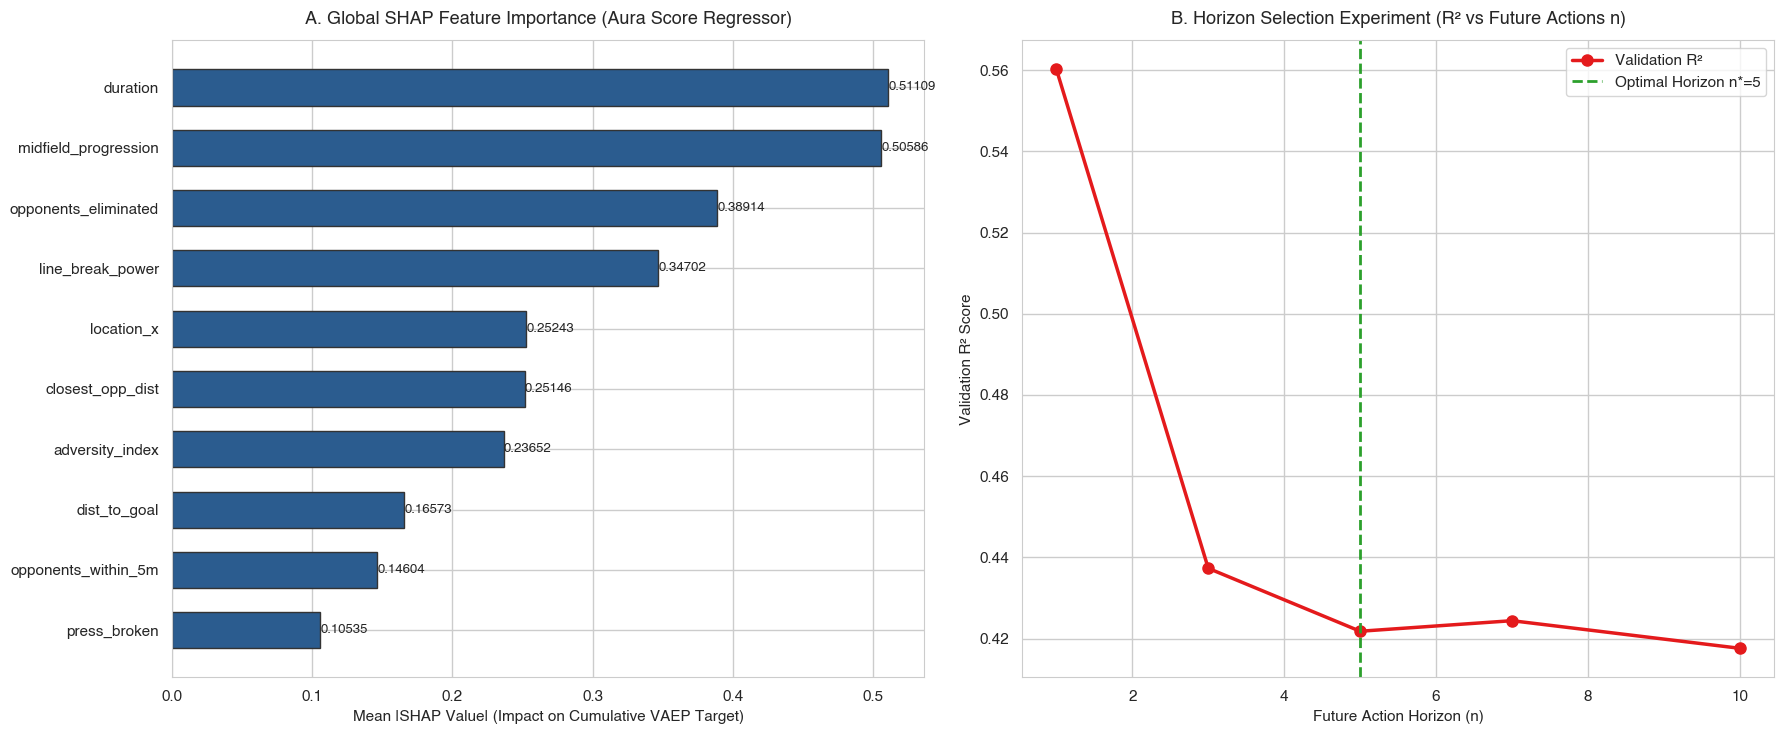

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
fig.patch.set_facecolor('#ffffff')

top_10 = shap_df.head(10)
axes[0].barh(top_10['Feature'], top_10['Mean_|SHAP|_Value'], color='#2b5c8f', edgecolor='#333', height=0.6)
axes[0].set_title('A. Global SHAP Feature Importance (Aura Score Regressor)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Mean |SHAP Value| (Impact on Cumulative VAEP Target)', fontsize=11)
axes[0].invert_yaxis()
for i, v in enumerate(top_10['Mean_|SHAP|_Value']):
    axes[0].text(v + 0.0003, i, f'{v:.5f}', va='center', fontweight='bold', fontsize=9.5)

axes[1].plot(n_exp_df['n'], n_exp_df['Val_R2'], marker='o', lw=2.5, color='#e41a1c', markersize=8, label='Validation R²')
axes[1].axvline(5, color='#2ca02c', linestyle='--', lw=2, label='Optimal Horizon n*=5')
axes[1].set_title('B. Horizon Selection Experiment (R² vs Future Actions n)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Future Action Horizon (n)', fontsize=11)
axes[1].set_ylabel('Validation R² Score', fontsize=11)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig7_shap_importance_and_horizon_selection.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 8: Positional Validation — Verifying Higher Scores for Midfielders

In [9]:
df_360['aura_score_pred'] = rf_model.predict(X)

# 1. Positional Summary Table Across All 23 Positions
pos_analysis = df_360.groupby('position').agg(
    mean_aura_score=('aura_score_pred', 'mean'),
    std_aura_score=('aura_score_pred', 'std'),
    total_actions=('event_id', 'count')
).sort_values(by='mean_aura_score', ascending=False).round(4)

pos_analysis.to_csv(os.path.join(DATA_DIR, 'aura_score_by_position.csv'))
print("=== TABLE 1: AVERAGE PREDICTED AURA SCORE ACROSS ALL 23 POSITIONS ===")
display(pos_analysis)

print()
print("=== TABLE 2: TOURNAMENT CATALYTIC AURA LEADERBOARD (QUALITY RATE & TOTAL WORK) ===")
# 2. Pure Natural Leaderboard Sorted by Total Tournament Catalytic Aura
top_players = df_360.groupby('player').agg(
    aura_score=('aura_score_pred', 'mean'),
    total_catalytic_aura=('aura_score_pred', 'sum'),
    actions=('event_id', 'count'),
    matches=('match_id', 'nunique'),
    position=('position', 'first'),
    team=('team', 'first')
).sort_values(by='total_catalytic_aura', ascending=False).round(2)

top_players.to_csv(os.path.join(DATA_DIR, 'top_players_aura_leaderboard.csv'))
display(top_players.head(30))

=== TABLE 1: AVERAGE PREDICTED AURA SCORE ACROSS ALL 23 POSITIONS ===


,mean_aura_score,std_aura_score,total_actions
position,,,
Center Defensive Midfield,5.6359,2.3997,3313
Right Defensive Midfield,5.5629,2.3778,2526
Left Defensive Midfield,5.5613,2.4082,2675
Left Center Midfield,5.4058,2.2256,3298
Right Center Midfield,5.3402,2.2089,3324
Right Center Forward,5.2452,2.4329,694
Center Attacking Midfield,5.2442,2.4099,1479
Left Center Back,5.1943,2.3893,5709
Left Back,5.1424,2.4692,3905



=== TABLE 2: TOURNAMENT CATALYTIC AURA LEADERBOARD (QUALITY RATE & TOTAL WORK) ===


,aura_score,total_catalytic_aura,actions,matches,position,team
player,,,,,,
Harry Maguire,5.17,4754.81,920,4,Left Center Back,England
Luka Modrić,5.69,4344.59,764,3,Right Defensive Midfield,Croatia
John Stones,5.04,4192.28,832,4,Right Center Back,England
Aymeric Laporte,5.62,4161.38,741,2,Left Center Back,Spain
Mateo Kovačić,5.59,4087.90,731,3,Left Defensive Midfield,Croatia
Marco Verratti,5.40,3900.80,723,3,Left Center Midfield,Italy
Enzo Fernandez,5.69,3888.92,683,3,Center Defensive Midfield,Argentina
Luke Shaw,4.99,3823.56,767,4,Left Back,England
Jorge Luiz Frello Filho,5.38,3609.35,671,3,Center Defensive Midfield,Italy


## Step 9: SHAP Dependence Plot — Line-Breaking Penetration & Forward Options

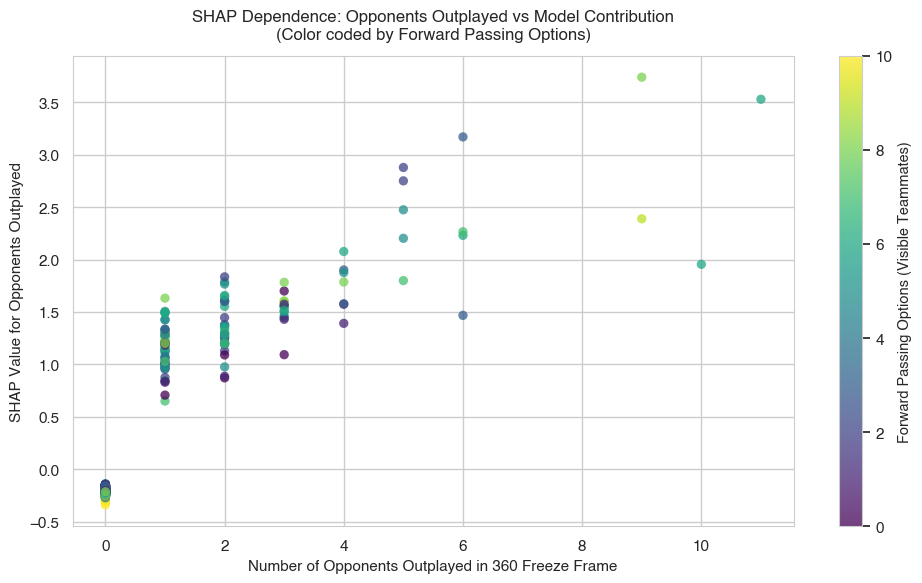

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#ffffff')

feat_idx = list(X.columns).index('opponents_eliminated')
shap_vals_feat = shap_values[:, feat_idx]
feature_vals = shap_sample['opponents_eliminated']

scatter = ax.scatter(feature_vals, shap_vals_feat, c=shap_sample['forward_passing_options'], cmap='viridis', alpha=0.75, s=45, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Forward Passing Options (Visible Teammates)', fontsize=10.5)
ax.set_title('SHAP Dependence: Opponents Outplayed vs Model Contribution\n(Color coded by Forward Passing Options)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Number of Opponents Outplayed in 360 Freeze Frame', fontsize=11)
ax.set_ylabel('SHAP Value for Opponents Outplayed', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig8_shap_dependence_opponents_eliminated.png'), dpi=300, bbox_inches='tight')
plt.show()

